# Fleet MOT Failure Risk Model

## Notebook 03: Exploratory Data Analysis

This notebook explores the cleaned 2024 MOT sample dataset.

The purpose of this notebook is to analyse:

- Overall MOT pass and fail rates
- MOT failure rate by vehicle age band
- MOT failure rate by mileage band
- MOT failure rate by make
- MOT failure rate by fuel type
- MOT failure rate by vehicle class
- Monthly MOT outcome patterns
- Key insights for fleet maintenance and risk planning

The outputs from this notebook will support SQL analysis, Power BI dashboarding and future MOT failure risk modelling.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define project paths

processed_data_path = Path("../data/processed")

cleaned_file = processed_data_path / "mot_2024_cleaned_sample.csv"

print("Cleaned file exists:", cleaned_file.exists())

Cleaned file exists: True


In [3]:
# Load cleaned MOT sample dataset

mot = pd.read_csv(cleaned_file, low_memory=False)

print("Dataset loaded successfully.")
print("Rows:", mot.shape[0])
print("Columns:", mot.shape[1])

Dataset loaded successfully.
Rows: 600000
Columns: 18


In [4]:
# Preview first rows

mot.head()

,test_result,test_date,first_use_date,test_mileage,make,model,fuel_type,vehicle_class,colour,postcode_area,source_file,is_fail,is_pass,mot_outcome,vehicle_age_years,mileage_band,vehicle_age_band,test_month
0,P,2024-01-02,2010-09-01,71614.0,PORSCHE,911,PE,4,RED,OX,TEST_RESULT_202401.CSV,False,True,Pass,13.336071,60k-100k,10-15 years,2024-01
1,P,2024-01-02,2010-09-01,71614.0,PORSCHE,911,PE,4,RED,OX,TEST_RESULT_202401.CSV,False,True,Pass,13.336071,60k-100k,10-15 years,2024-01
2,P,2024-01-02,2010-09-01,71614.0,PORSCHE,911,PE,4,RED,OX,TEST_RESULT_202401.CSV,False,True,Pass,13.336071,60k-100k,10-15 years,2024-01
3,P,2024-01-02,2010-09-01,71614.0,PORSCHE,911,PE,4,RED,OX,TEST_RESULT_202401.CSV,False,True,Pass,13.336071,60k-100k,10-15 years,2024-01
4,P,2024-01-02,2010-09-01,71614.0,PORSCHE,911,PE,4,RED,OX,TEST_RESULT_202401.CSV,False,True,Pass,13.336071,60k-100k,10-15 years,2024-01


In [5]:
# Check columns

mot.columns.tolist()

['test_result',
 'test_date',
 'first_use_date',
 'test_mileage',
 'make',
 'model',
 'fuel_type',
 'vehicle_class',
 'colour',
 'postcode_area',
 'source_file',
 'is_fail',
 'is_pass',
 'mot_outcome',
 'vehicle_age_years',
 'mileage_band',
 'vehicle_age_band',
 'test_month']

In [6]:
# Check data types

mot.info()

<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   test_result        600000 non-null  str    
 1   test_date          600000 non-null  str    
 2   first_use_date     600000 non-null  str    
 3   test_mileage       595096 non-null  float64
 4   make               600000 non-null  str    
 5   model              599999 non-null  str    
 6   fuel_type          600000 non-null  str    
 7   vehicle_class      600000 non-null  int64  
 8   colour             600000 non-null  str    
 9   postcode_area      600000 non-null  str    
 10  source_file        600000 non-null  str    
 11  is_fail            600000 non-null  bool   
 12  is_pass            600000 non-null  bool   
 13  mot_outcome        600000 non-null  str    
 14  vehicle_age_years  600000 non-null  float64
 15  mileage_band       595096 non-null  str    
 16  vehicle_age_b

## Overall MOT Outcome Summary

This section calculates the overall MOT pass/fail split in the cleaned sample dataset.

In [7]:
# MOT outcome count and percentage

outcome_summary = (
    mot["mot_outcome"]
    .value_counts(dropna=False)
    .reset_index()
)

outcome_summary.columns = ["mot_outcome", "test_count"]

outcome_summary["percentage"] = round(
    outcome_summary["test_count"] / outcome_summary["test_count"].sum() * 100,
    2
)

outcome_summary

,mot_outcome,test_count,percentage
0,Pass,460451,76.74
1,Fail,107756,17.96
2,Other,31793,5.30


In [8]:
# Create KPI summary

total_tests = len(mot)
failed_tests = mot["is_fail"].sum()
passed_tests = mot["is_pass"].sum()
failure_rate = failed_tests / total_tests
pass_rate = passed_tests / total_tests
average_mileage = mot["test_mileage"].mean()
average_vehicle_age = mot["vehicle_age_years"].mean()

kpi_summary = pd.DataFrame([
    {"KPI": "Total MOT Tests", "Value": total_tests},
    {"KPI": "Passed MOT Tests", "Value": passed_tests},
    {"KPI": "Failed MOT Tests", "Value": failed_tests},
    {"KPI": "Failure Rate", "Value": f"{failure_rate:.2%}"},
    {"KPI": "Pass Rate", "Value": f"{pass_rate:.2%}"},
    {"KPI": "Average Test Mileage", "Value": round(average_mileage, 0)},
    {"KPI": "Average Vehicle Age", "Value": round(average_vehicle_age, 2)}
])

kpi_summary

,KPI,Value
0,Total MOT Tests,600000
1,Passed MOT Tests,460451
2,Failed MOT Tests,107756
3,Failure Rate,17.96%
4,Pass Rate,76.74%
5,Average Test Mileage,78966.0
6,Average Vehicle Age,10.91


## Failure Rate by Vehicle Age Band

This section analyses how MOT failure rate changes as vehicles get older.

This is useful for fleet maintenance planning because vehicle age can be linked to increased defect and failure risk.

In [9]:
# Failure rate by vehicle age band

age_band_summary = (
    mot
    .groupby("vehicle_age_band", observed=False)
    .agg(
        test_count=("mot_outcome", "count"),
        failed_tests=("is_fail", "sum"),
        passed_tests=("is_pass", "sum"),
        average_mileage=("test_mileage", "mean")
    )
    .reset_index()
)

age_band_summary["failure_rate"] = age_band_summary["failed_tests"] / age_band_summary["test_count"]

age_band_summary

,vehicle_age_band,test_count,failed_tests,passed_tests,average_mileage,failure_rate
0,0-3 years,23089,1727,20633,25921.666014,0.074798
1,10-15 years,145260,32866,103167,98289.538348,0.226256
2,15-20 years,91043,23809,60539,110841.824332,0.261514
3,20+ years,42395,9985,29713,100656.850531,0.235523
4,3-5 years,64062,5962,55779,37702.109455,0.093066
5,5-8 years,148193,18662,123464,60393.409319,0.125930
6,8-10 years,85958,14745,67156,79539.432336,0.171537


## Failure Rate by Mileage Band

This section analyses how MOT failure rate changes across mileage bands.

Mileage can indicate vehicle usage and wear, making it useful for fleet maintenance and replacement planning.

In [10]:
# Failure rate by mileage band

mileage_band_summary = (
    mot
    .groupby("mileage_band", observed=False)
    .agg(
        test_count=("mot_outcome", "count"),
        failed_tests=("is_fail", "sum"),
        passed_tests=("is_pass", "sum"),
        average_vehicle_age=("vehicle_age_years", "mean")
    )
    .reset_index()
)

mileage_band_summary["failure_rate"] = mileage_band_summary["failed_tests"] / mileage_band_summary["test_count"]

mileage_band_summary

,mileage_band,test_count,failed_tests,passed_tests,average_vehicle_age,failure_rate
0,0-30k,86396,6780,76966,6.791095,0.078476
1,100k-150k,122234,30642,84113,13.906536,0.250683
2,150k-200k,38114,9873,25656,14.962887,0.259039
3,200k+,11263,2907,7597,14.534377,0.258102
4,30k-60k,154928,20769,128388,8.643180,0.134056
5,60k-100k,182161,36263,136640,11.604788,0.199071


## Failure Rate by Vehicle Make

This section analyses MOT failure patterns by vehicle make.

To avoid misleading results from very small sample sizes, makes with fewer than 500 tests will be excluded from the main ranking.

In [11]:
# Failure rate by vehicle make

make_summary = (
    mot
    .groupby("make")
    .agg(
        test_count=("mot_outcome", "count"),
        failed_tests=("is_fail", "sum"),
        passed_tests=("is_pass", "sum"),
        average_mileage=("test_mileage", "mean"),
        average_vehicle_age=("vehicle_age_years", "mean")
    )
    .reset_index()
)

make_summary["failure_rate"] = make_summary["failed_tests"] / make_summary["test_count"]

# Filter makes with enough records for more reliable comparison
make_summary_filtered = make_summary[make_summary["test_count"] >= 500].copy()

make_summary_filtered.sort_values(by="failure_rate", ascending=False).head(20)

,make,test_count,failed_tests,passed_tests,average_mileage,average_vehicle_age,failure_rate
359,TALBOT,693,209,448,87424.600291,31.757228,0.301587
185,IVECO,719,190,475,120859.246398,12.775284,0.264256
314,RENAULT,18422,4762,12572,97835.688058,12.739869,0.258495
277,NISSAN,22897,5671,16084,80825.059946,10.961017,0.247674
243,MAZDA,2209,539,1549,95848.180365,13.753566,0.244002
84,CITROEN,7660,1800,5328,84331.150132,12.122048,0.234987
139,FORD,116488,26255,81890,94850.414053,12.724102,0.225388
343,SMART (MCC),1484,332,1061,71069.146475,16.161268,0.223720
329,SAAB,819,178,585,108056.594595,20.084452,0.217338
9,ALFA ROMEO,2789,600,2054,94283.367509,12.540123,0.215131


In [12]:
# Failure rate by fuel type

fuel_summary = (
    mot
    .groupby("fuel_type")
    .agg(
        test_count=("mot_outcome", "count"),
        failed_tests=("is_fail", "sum"),
        passed_tests=("is_pass", "sum"),
        average_mileage=("test_mileage", "mean"),
        average_vehicle_age=("vehicle_age_years", "mean")
    )
    .reset_index()
)

fuel_summary["failure_rate"] = fuel_summary["failed_tests"] / fuel_summary["test_count"]

fuel_summary.sort_values(by="test_count", ascending=False)

,fuel_type,test_count,failed_tests,passed_tests,average_mileage,average_vehicle_age,failure_rate
11,PE,296546,51989,228326,64421.722959,11.847726,0.175315
0,DI,269166,52800,202120,98017.150440,10.609466,0.196161
7,HY,26771,2272,23563,51566.679757,4.854800,0.084868
2,EL,2291,164,2015,28723.818981,4.040432,0.071584
8,HYBRID ELECTRIC (CLEAN),2128,185,1773,110201.023685,7.521932,0.086936
3,ELECTRIC,1936,252,1629,80596.379727,7.130841,0.130165
1,ED,956,66,872,38403.740818,3.423906,0.069038
9,LP,109,17,71,146757.047170,22.026010,0.155963
6,GB,71,8,62,36574.873239,5.261417,0.112676
10,OT,22,3,16,127355.900000,15.171925,0.136364


In [13]:
# Failure rate by vehicle class

vehicle_class_summary = (
    mot
    .groupby("vehicle_class")
    .agg(
        test_count=("mot_outcome", "count"),
        failed_tests=("is_fail", "sum"),
        passed_tests=("is_pass", "sum"),
        average_mileage=("test_mileage", "mean"),
        average_vehicle_age=("vehicle_age_years", "mean")
    )
    .reset_index()
)

vehicle_class_summary["failure_rate"] = vehicle_class_summary["failed_tests"] / vehicle_class_summary["test_count"]

vehicle_class_summary.sort_values(by="test_count", ascending=False)

,vehicle_class,test_count,failed_tests,passed_tests,average_mileage,average_vehicle_age,failure_rate
3,4,552607,99155,424531,77899.005902,10.990533,0.179431
5,7,34366,7551,24564,117538.024982,8.466723,0.219723
1,2,10402,635,9272,21167.930893,14.542861,0.061046
0,1,1938,304,1526,11848.106085,11.074005,0.156863
4,5,597,107,475,77425.402098,9.400780,0.179229
2,3,90,4,83,18619.264368,20.040399,0.044444


## Monthly MOT Outcome Trend

This section checks whether pass/fail volumes vary by test month in the 2024 sample.

In [14]:
# Monthly MOT outcome summary

monthly_summary = (
    mot
    .groupby("test_month")
    .agg(
        test_count=("mot_outcome", "count"),
        failed_tests=("is_fail", "sum"),
        passed_tests=("is_pass", "sum"),
        average_mileage=("test_mileage", "mean"),
        average_vehicle_age=("vehicle_age_years", "mean")
    )
    .reset_index()
)

monthly_summary["failure_rate"] = monthly_summary["failed_tests"] / monthly_summary["test_count"]

monthly_summary.sort_values(by="test_month")

,test_month,test_count,failed_tests,passed_tests,average_mileage,average_vehicle_age,failure_rate
0,2024-01,50000,9532,37682,84330.323174,10.829700,0.19064
1,2024-02,50000,9271,38078,82600.574731,10.820779,0.18542
2,2024-03,50000,8635,38673,76520.035029,10.197157,0.17270
3,2024-04,50000,8650,38718,76882.653710,10.752344,0.17300
4,2024-05,50000,8461,38887,75784.150079,10.863671,0.16922
5,2024-06,50000,8684,38770,75858.765216,10.909505,0.17368
6,2024-07,50000,8798,38509,77464.134635,10.998030,0.17596
7,2024-08,50000,8852,38568,77682.502149,11.107390,0.17704
8,2024-09,50000,8967,38584,77793.251909,10.643149,0.17934
9,2024-10,50000,9702,37686,83395.017404,11.185542,0.19404


## Initial Visual Exploration

The following charts provide a quick visual overview of MOT failure patterns.

More polished visuals will later be created in Power BI.

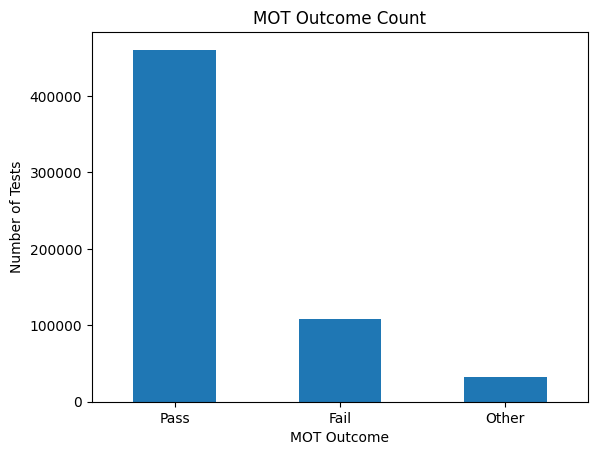

In [15]:
# Chart: MOT outcome split

outcome_summary.set_index("mot_outcome")["test_count"].plot(kind="bar")

plt.title("MOT Outcome Count")
plt.xlabel("MOT Outcome")
plt.ylabel("Number of Tests")
plt.xticks(rotation=0)
plt.show()

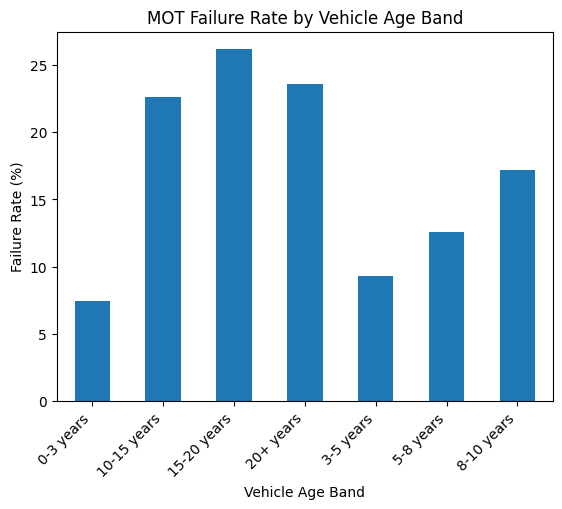

In [16]:
# Chart: Failure rate by vehicle age band

age_chart = age_band_summary.copy()
age_chart["failure_rate_percent"] = age_chart["failure_rate"] * 100

age_chart.set_index("vehicle_age_band")["failure_rate_percent"].plot(kind="bar")

plt.title("MOT Failure Rate by Vehicle Age Band")
plt.xlabel("Vehicle Age Band")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

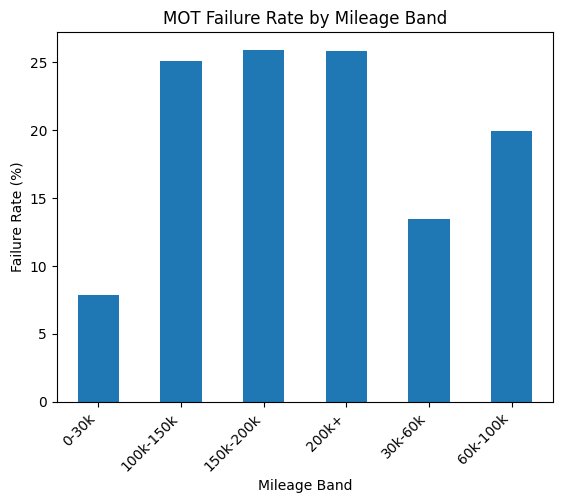

In [17]:
# Chart: Failure rate by mileage band

mileage_chart = mileage_band_summary.copy()
mileage_chart["failure_rate_percent"] = mileage_chart["failure_rate"] * 100

mileage_chart.set_index("mileage_band")["failure_rate_percent"].plot(kind="bar")

plt.title("MOT Failure Rate by Mileage Band")
plt.xlabel("Mileage Band")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Export EDA Summary Tables

The summary tables created in this notebook will be exported into the processed data folder.

These outputs will support SQL analysis and Power BI dashboard development.

In [18]:
# Export EDA summary tables

outcome_summary.to_csv(processed_data_path / "mot_outcome_summary.csv", index=False)
kpi_summary.to_csv(processed_data_path / "mot_kpi_summary.csv", index=False)
age_band_summary.to_csv(processed_data_path / "mot_age_band_summary.csv", index=False)
mileage_band_summary.to_csv(processed_data_path / "mot_mileage_band_summary.csv", index=False)
make_summary_filtered.to_csv(processed_data_path / "mot_make_summary.csv", index=False)
fuel_summary.to_csv(processed_data_path / "mot_fuel_summary.csv", index=False)
vehicle_class_summary.to_csv(processed_data_path / "mot_vehicle_class_summary.csv", index=False)
monthly_summary.to_csv(processed_data_path / "mot_monthly_summary.csv", index=False)

print("EDA summary tables exported successfully.")

EDA summary tables exported successfully.


In [19]:
# Check exported summary files

summary_files = [
    "mot_outcome_summary.csv",
    "mot_kpi_summary.csv",
    "mot_age_band_summary.csv",
    "mot_mileage_band_summary.csv",
    "mot_make_summary.csv",
    "mot_fuel_summary.csv",
    "mot_vehicle_class_summary.csv",
    "mot_monthly_summary.csv"
]

for file_name in summary_files:
    file_path = processed_data_path / file_name
    print(file_name, file_path.exists())

mot_outcome_summary.csv True
mot_kpi_summary.csv True
mot_age_band_summary.csv True
mot_mileage_band_summary.csv True
mot_make_summary.csv True
mot_fuel_summary.csv True
mot_vehicle_class_summary.csv True
mot_monthly_summary.csv True


## Initial EDA Observations

This notebook explored MOT failure patterns using the cleaned 2024 sample dataset.

The analysis reviewed:

- Overall pass/fail split
- MOT failure rate by vehicle age band
- MOT failure rate by mileage band
- MOT failure rate by make
- MOT failure rate by fuel type
- MOT failure rate by vehicle class
- Monthly MOT outcome trends

The exported summary tables will be used later for SQL reporting and Power BI dashboard development.

The next stage will focus on creating a basic MOT failure risk model.